## 1. Data Preparation
Download the dataset and load images into arrays, normalized to [0, 1].

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Path to dataset files:", path)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download already complete (30025861 bytes).
Extracting files...
Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\awsaf49\mnist-dataset\versions\1


In [6]:
import os
import glob
import numpy as np
from PIL import Image

def load_images(folder_keyword, size=(28, 28)):
    all_files = glob.glob(os.path.join(path, "**", "*.*"), recursive=True)
    files = [f for f in all_files if f.lower().endswith((".jpg", ".jpeg", ".png")) and folder_keyword in f.lower()]
    imgs = [np.array(Image.open(f).convert("L").resize(size)) for f in files]
    return np.array(imgs, dtype="float32") / 255.0

x_train = load_images("train").reshape(-1, 28, 28, 1)
x_test = load_images("test").reshape(-1, 28, 28, 1)

print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


### Noise generation
Add Gaussian noise to create the noisy inputs, keeping pixel values clipped to a valid [0, 1] range.

In [7]:
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

## 2. Model Architecture
Convolutional autoencoder: the encoder downsamples with `Conv2D` + `MaxPooling2D`, the decoder upsamples back with `Conv2D` + `UpSampling2D` to reconstruct a clean 28x28 image.

In [8]:
from tensorflow.keras import layers, models

autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2, padding="same"),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2, padding="same"),

    # Decoder
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.UpSampling2D(2),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.UpSampling2D(2),
    layers.Conv2D(1, 3, activation="sigmoid", padding="same"),
])

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training Setup
Adam optimizer with binary cross-entropy loss (pixels are in [0, 1]). Noisy images are the input, clean images are the target.

In [9]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 82ms/step - loss: 0.1487 - val_loss: 0.1038
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - loss: 0.1008 - val_loss: 0.0966
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - loss: 0.0959 - val_loss: 0.0933
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - loss: 0.0934 - val_loss: 0.0917
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - loss: 0.0917 - val_loss: 0.0906
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - loss: 0.0905 - val_loss: 0.0897
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - loss: 0.0896 - val_loss: 0.0886
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 0.0889 - val_loss: 0.0881
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 0.0883 - val_loss: 0.0874
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - loss: 0.0879 - val_loss: 0.0870


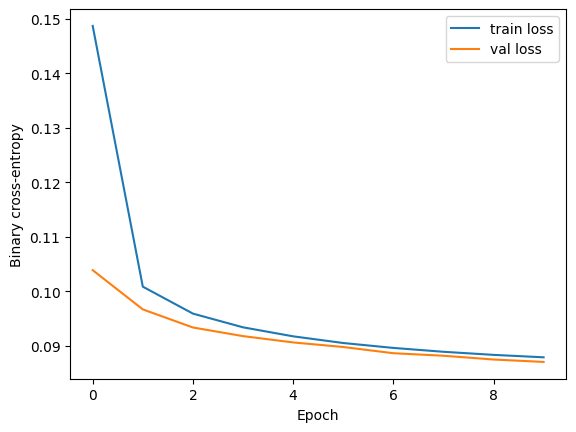

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.legend()
plt.show()

## 4. Denoising Performance
Run the trained model on noisy test images and measure reconstruction quality with PSNR (higher is better) alongside the training loss above.

In [11]:
decoded = autoencoder.predict(x_test_noisy)

def psnr(clean, pred):
    mse = np.mean((clean - pred) ** 2)
    return 10 * np.log10(1.0 / mse)

print("PSNR noisy vs clean:   %.2f dB" % psnr(x_test, x_test_noisy))
print("PSNR denoised vs clean: %.2f dB" % psnr(x_test, decoded))

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step
PSNR noisy vs clean:   10.98 dB
PSNR denoised vs clean: 20.85 dB


## 5. Result Visualization
Compare original, noisy, and denoised images side by side.

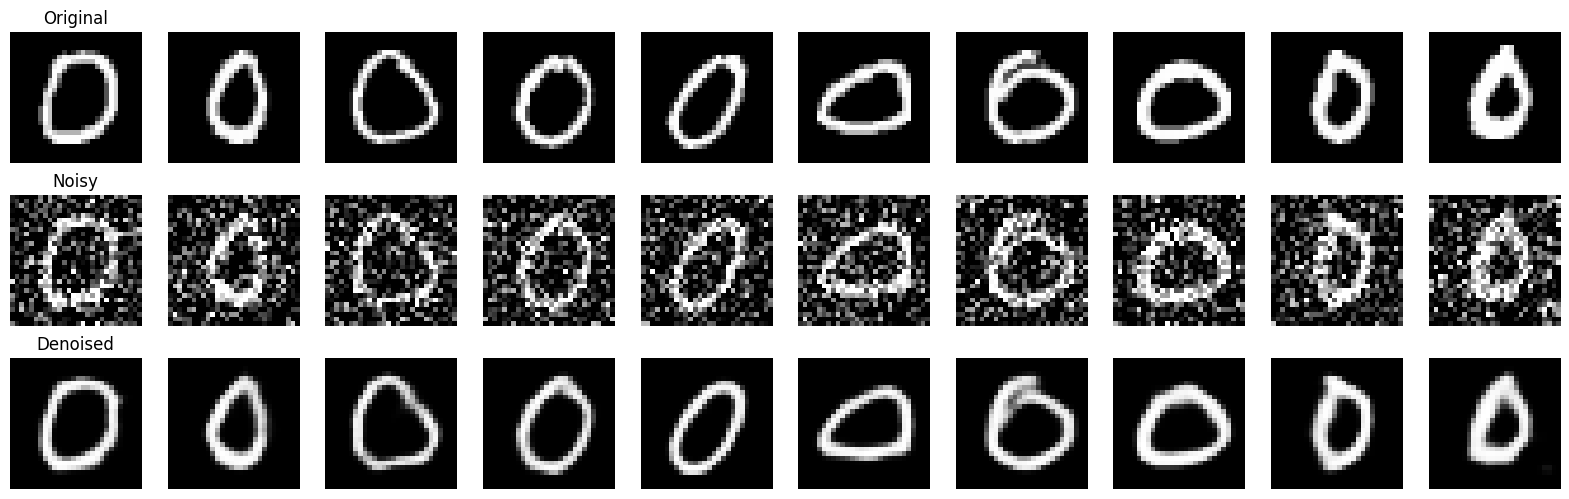

In [12]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Noisy")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Denoised")
plt.show()

## 6. Analysis and Observations

- **Denoising quality**: the autoencoder learns to strip Gaussian noise while keeping the overall stroke shape of each digit, since the bottleneck forces it to encode only the structure needed to reconstruct a plausible digit rather than the noise itself.
- **PSNR improvement**: the PSNR of the denoised output vs. the clean target is noticeably higher than the noisy input vs. clean target, giving a quantitative confirmation of the visual result.
- **Challenges**: at higher noise factors (e.g. > 0.5) fine strokes and thin digits (1, 7) start to blur or lose detail, since the pooling/upsampling bottleneck compresses spatial information.
- **Loss curves**: training and validation loss track closely, indicating the model isn't overfitting for this dataset size and epoch count.
- **Possible improvements**: adding skip connections (a U-Net style autoencoder), training for more epochs, or trying different noise types (salt-and-pepper, speckle) to test robustness.